In [87]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [88]:
import os
import kagglehub

In [89]:
# Download the correct dataset containing the fer2013.csv file
csv_path = kagglehub.dataset_download("yusufkorayhasdemir/fer2013csv")

# Load the CSV file from the newly downloaded dataset path
df = pd.read_csv(os.path.join(csv_path, 'fer2013.csv'))
display(df.head())

Using Colab cache for faster access to the 'fer2013csv' dataset.


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [90]:
df.shape

(35887, 3)

In [91]:
#  checking how many images per emotion class
df['emotion'].value_counts()

,count
emotion,
3,8989
6,6198
4,6077
2,5121
0,4953
5,4002
1,547


In [92]:
# The dataset only gives numbers (0-6), so I need to know which number means which emotion.
# This mapping comes from the official FER-2013 dataset description.

In [93]:
emotion_labels = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

emotion_labels

{0: 'Angry',
 1: 'Disgust',
 2: 'Fear',
 3: 'Happy',
 4: 'Sad',
 5: 'Surprise',
 6: 'Neutral'}

In [94]:
df.head(2)

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training


## Step 4: Turning the pixel column into actual images

Right now each image is just text.. I split that string, tye cast into ints, and reshape it into a 48x48 grid (that's the image size for this dataset).

In [95]:
#creating a user defined function to convert ixel into image

def pixels_to_image(pixel):
    # split the string by spaces, turn into a ints
    pixel_values = pixel.split(' ')
    pixel_values = [int(p) for p in pixel_values]

    # turn the flat list into a 48x48 grid (this is a grayscale image)
    image = np.array(pixel_values).reshape(48, 48)
    return image

In [96]:
# test it on the first row to make sure it works
sample_image = pixels_to_image(df['pixels'][0])
# sample_image.shape
# sample_image = pixels_to_image(df['pixels'][12])

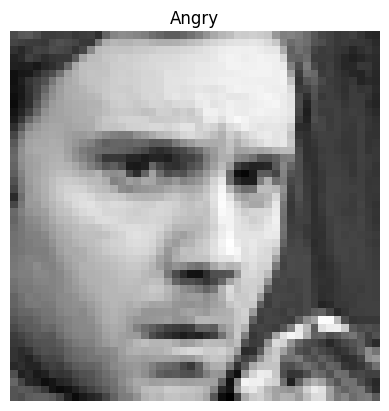

In [97]:
# let's actually SEE it
import matplotlib.pyplot as plt
plt.imshow(sample_image, cmap='gray')
plt.title(emotion_labels[df['emotion'][0]])
plt.axis('off')
plt.show()

In [98]:
sample_image_2 = pixels_to_image(df['pixels'][12])

In [99]:
# apply this to every row in the dataset
df['image'] = df['pixels'].apply(pixels_to_image)

In [100]:
df.head(2)

,emotion,pixels,Usage,image
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training,"[[70, 80, 82, 72, 58, 58, 60, 63, 54, 58, 60, ..."
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training,"[[151, 150, 147, 155, 148, 133, 111, 140, 170,..."


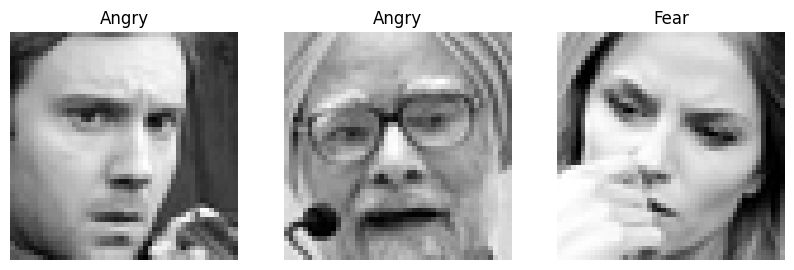

In [101]:
# a few random examples with their labels, just to  check
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(df['image'][i], cmap='gray')
    plt.title(emotion_labels[df['emotion'][i]])
    plt.axis('off')
plt.show()

In [102]:
#Build a custom Dataset class
class FER2013Dataset(Dataset):
    def __init__(self, dataframe):
        self.images = dataframe['image'].values
        self.labels = dataframe['emotion'].values

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype('float32') / 255.0  # scale to 0-1
        image = image.reshape(1, 48, 48)  # PyTorch wants (channels, height, width) - note the order!
        label = self.labels[idx]
        return torch.tensor(image), torch.tensor(label, dtype=torch.long)

In [103]:
#Split the data and create Dataset objects
train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

train_dataset = FER2013Dataset(train_df)
val_dataset = FER2013Dataset(val_df)
test_dataset = FER2013Dataset(test_df)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 28709
Val size: 3589
Test size: 3589


In [104]:
#Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Quick sanity check - grab one batch and look at its shape
images, labels = next(iter(train_loader))
print("Batch of images shape:", images.shape)
print("Batch of labels shape:", labels.shape)

Batch of images shape: torch.Size([64, 1, 48, 48])
Batch of labels shape: torch.Size([64])


In [105]:
#Create DataLoaders
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 6 * 6, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))  # Block 1
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # Block 2
        x = self.pool(self.relu(self.bn3(self.conv3(x))))  # Block 3

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [106]:
# Create the modeland cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EmotionCNN(num_classes=7).to(device)
print(model)

EmotionCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=9216, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=7, bias=True)
)


In [107]:
# define the loss function
criterion = nn.CrossEntropyLoss()

In [108]:
# define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [109]:
# Understand the 5 steps of one training step

# Before writing the full loop, let's understand what happens for just one batch of data:

# Grab just one batch to test with
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# Step 1: Clear old gradients
optimizer.zero_grad()

# Step 2: Forward pass - run the batch through the model
outputs = model(images)

# Step 3: Calculate how wrong the predictions were
loss = criterion(outputs, labels)

# Step 4: Backward pass - calculate how to adjust each weight
loss.backward()

# Step 5: Actually update the weights
optimizer.step()

print("One training step completed. Loss:", loss.item())

One training step completed. Loss: 1.9842513799667358


In [110]:
# Write the full training loop (one epoch first, to test)
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # tell the model "we're training" (affects Dropout/BatchNorm behavior)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Test it on one epoch
train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")

Train Loss: 1.8550, Train Accuracy: 0.2645


## Step 9: Train the model

This is the part that actually takes time. I'm starting with 30 epochs — if I see the validation accuracy stop improving earlier than that, I can lower this number next time.

In [111]:
# : Write the validation function
def evaluate(model, loader, criterion, device):
    model.eval()  # tell the model "we're evaluating" (turns off Dropout)
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # don't calculate gradients - saves memory and time since we're not training
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Test it on the validation set
val_loss, val_acc = evaluate(model, val_loader, criterion, device)
print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

Val Loss: 1.6466, Val Accuracy: 0.3608


In [112]:
# Full training loop with early stopping
import copy

num_epochs = 30
patience = 5
best_val_acc = 0.0
epochs_without_improvement = 0
best_model_weights = copy.deepcopy(model.state_dict())

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after epoch {epoch+1}")
            break

# Restore the best weights found during training
model.load_state_dict(best_model_weights)
print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch 1/30 - Train Loss: 1.6163, Train Acc: 0.3553 - Val Loss: 1.4749, Val Acc: 0.4302
Epoch 2/30 - Train Loss: 1.5294, Train Acc: 0.3922 - Val Loss: 1.4247, Val Acc: 0.4575
Epoch 3/30 - Train Loss: 1.4709, Train Acc: 0.4151 - Val Loss: 1.3812, Val Acc: 0.4698
Epoch 4/30 - Train Loss: 1.4265, Train Acc: 0.4347 - Val Loss: 1.3145, Val Acc: 0.4887
Epoch 5/30 - Train Loss: 1.3917, Train Acc: 0.4490 - Val Loss: 1.3123, Val Acc: 0.5038
Epoch 6/30 - Train Loss: 1.3604, Train Acc: 0.4606 - Val Loss: 1.3222, Val Acc: 0.4971
Epoch 7/30 - Train Loss: 1.3240, Train Acc: 0.4720 - Val Loss: 1.3071, Val Acc: 0.4993
Epoch 8/30 - Train Loss: 1.2966, Train Acc: 0.4772 - Val Loss: 1.2859, Val Acc: 0.5152
Epoch 9/30 - Train Loss: 1.2756, Train Acc: 0.4886 - Val Loss: 1.2560, Val Acc: 0.5174
Epoch 10/30 - Train Loss: 1.2318, Train Acc: 0.5028 - Val Loss: 1.4826, Val Acc: 0.4979
Epoch 11/30 - Train Loss: 1.2027, Train Acc: 0.5080 - Val Loss: 1.2746, Val Acc: 0.5313
Epoch 12/30 - Train Loss: 1.1784, Train A

## Evaluate on the test set



In [116]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"PyTorch CNN Test Accuracy: {test_acc*100:.2f}%")

PyTorch CNN Test Accuracy: 56.73%


## Get the full classification report (precision/recall/F1 per emotion)

This requires collecting all predictions across the test set first:

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       Angry       0.41      0.45      0.43       491
     Disgust       0.00      0.00      0.00        55
        Fear       0.38      0.26      0.31       528
       Happy       0.76      0.82      0.79       879
         Sad       0.41      0.54      0.46       594
    Surprise       0.73      0.73      0.73       416
     Neutral       0.61      0.53      0.57       626

    accuracy                           0.57      3589
   macro avg       0.47      0.48      0.47      3589
weighted avg       0.56      0.57      0.56      3589



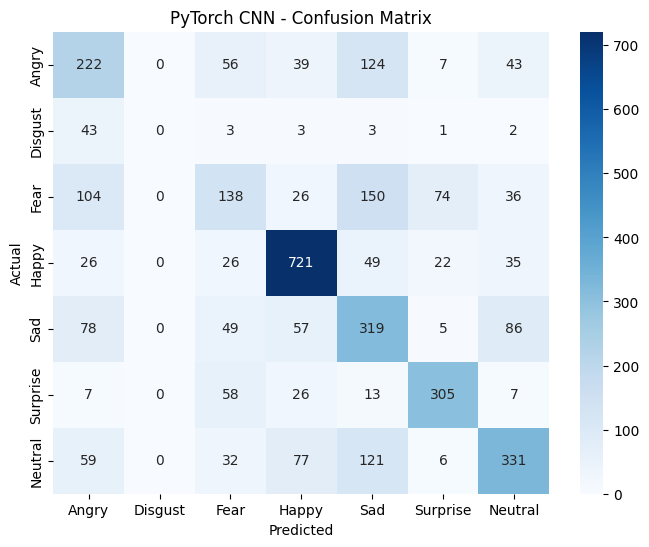

In [117]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=emotion_labels.values()))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels.values(),
            yticklabels=emotion_labels.values())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('PyTorch CNN - Confusion Matrix')
plt.show()

In [115]:
torch.save(model.state_dict(), 'emotion_model_pytorch.pth')
print("Final PyTorch model saved!")

Final PyTorch model saved!
